## **Loading dataset**

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

# Load the Shakespeare dataset
with open("shakespeare_train.txt", "r") as f:
    train_text = f.read()

# Take the first half of the file
half_text = train_text[:len(train_text) // 2]

# Calculate the split indices
train_split_idx = int(0.9 * len(half_text))
valid_split_idx = int(0.95 * len(half_text))

# Split the text
train_text = half_text[:train_split_idx]
valid_text = half_text[train_split_idx:valid_split_idx]
test_text = half_text[valid_split_idx:]

# Display a snippet of the text
print("Sample training text:", train_text[:200])
print("Sample validation text:", valid_text[:200])
print("Sample test text:", test_text[:200])

Num GPUs Available:  1
1 Physical GPUs, 1 Logical GPUs
Sample training text: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
Sample validation text: geons to the
tribunal plebs, to take up a matter of brawl
betwixt my uncle and one of the emperial's men.

MARCUS ANDRONICUS:
Why, sir, that is as fit as can be to serve for
your oration; and let him 
Sample test text: How will their grudging stomachs be provoked
To wilful disobedience, and rebel!
Beside, what infamy will there arise,
When foreign princes shall be certified
That for a toy, a thing of no regard,
King


## **vocab set and splitting**

In [5]:
# Create a vocabulary of unique characters
vocab = sorted(set(train_text))
vocab_size = len(vocab)
print(f'{vocab_size} unique characters')

# Create a mapping from characters to indices
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

# Encode each character in the text as a one-hot vector
def text_to_one_hot(text):
    text_as_int = np.array([char2idx[c] for c in text])
    one_hot_encoded = np.zeros((len(text_as_int), len(vocab)), dtype=np.float32)
    one_hot_encoded[np.arange(len(text_as_int)), text_as_int] = 1
    return one_hot_encoded

train_data = text_to_one_hot(train_text)
valid_data = text_to_one_hot(valid_text)
test_data = text_to_one_hot(test_text)

print("One-hot encoded training data shape:", train_data.shape)
print("One-hot encoded validation data shape:", valid_data.shape)
print("One-hot encoded test data shape:", test_data.shape)

# Function to split input and target
def split_input_target(one_hot_data):
    input_data = one_hot_data[:-1]
    target_data = one_hot_data[1:]
    return input_data, target_data

# Create input-target pairs
def create_dataset(data, seq_length):
    sequences = tf.data.Dataset.from_tensor_slices(data).batch(seq_length + 1, drop_remainder=True)
    dataset = sequences.map(lambda x: tf.py_function(split_input_target, [x], [tf.float32, tf.float32]))
    return dataset

# Create input-target pairs
seq_length = 100
sequences = tf.data.Dataset.from_tensor_slices(train_data).batch(seq_length + 1, drop_remainder=True)
dataset = sequences.map(lambda x: tf.py_function(split_input_target, [x], [tf.float32, tf.float32]))

# Batch the data
BATCH_SIZE = 64
BUFFER_SIZE = 10000
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

# Create input-target pairs
def create_dataset(data, seq_length):
    sequences = tf.data.Dataset.from_tensor_slices(data).batch(seq_length + 1, drop_remainder=True)
    dataset = sequences.map(lambda x: tf.py_function(split_input_target, [x], [tf.float32, tf.float32]))
    return dataset

# Prepare validation data
valid_sequences = tf.data.Dataset.from_tensor_slices(valid_data).batch(seq_length + 1, drop_remainder=True)
valid_dataset = valid_sequences.map(lambda x: tf.py_function(split_input_target, [x], [tf.float32, tf.float32])).batch(BATCH_SIZE, drop_remainder=True)

67 unique characters
One-hot encoded training data shape: (1958090, 67)
One-hot encoded validation data shape: (108783, 67)
One-hot encoded test data shape: (108783, 67)


# **RNN model**

In [6]:
from tensorflow.keras.layers import SimpleRNN
# Define the RNN model with Dropout
def build_rnn_model(vocab_size, rnn_units, batch_size):
    model = Sequential([
        SimpleRNN(rnn_units, return_sequences=True, stateful=True, recurrent_initializer='glorot_uniform', batch_input_shape=[batch_size, None, vocab_size]),
        Dropout(0.2),
        Dense(vocab_size)
    ])
    return model

## **running standard RNN model**

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (64, None, 1024)          1118208   
                                                                 
 dropout (Dropout)           (64, None, 1024)          0         
                                                                 
 dense (Dense)               (64, None, 67)            68675     
                                                                 
Total params: 1,186,883
Trainable params: 1,186,883
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
302/302 [==============================] - 30s 66ms/step - loss: 2.6210 - val_loss: 2.2650
Epoch 2/30
302/302 [==============================] - 29s 67ms/step - loss: 2.1583 - val_loss: 2.1769
Epoch 3/30
302/302 [==============================] - 53s 139ms/step - loss: 2.0864 - val_loss: 2.1139
Epo

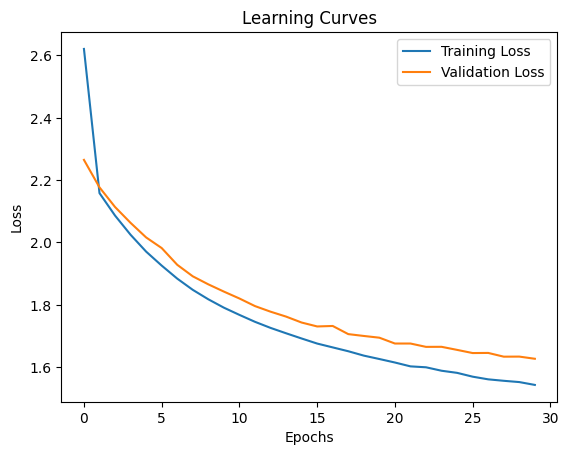

Epoch 1: Training Loss = 2.620952606201172, Validation Loss = 2.265005350112915
Epoch 2: Training Loss = 2.158341407775879, Validation Loss = 2.1768686771392822
Epoch 3: Training Loss = 2.0863547325134277, Validation Loss = 2.113863945007324
Epoch 4: Training Loss = 2.024717330932617, Validation Loss = 2.0629069805145264
Epoch 5: Training Loss = 1.9706918001174927, Validation Loss = 2.016211748123169
Epoch 6: Training Loss = 1.9258946180343628, Validation Loss = 1.9821574687957764
Epoch 7: Training Loss = 1.8841171264648438, Validation Loss = 1.9284437894821167
Epoch 8: Training Loss = 1.8480689525604248, Validation Loss = 1.8914906978607178
Epoch 9: Training Loss = 1.8177522420883179, Validation Loss = 1.8657087087631226
Epoch 10: Training Loss = 1.790902853012085, Validation Loss = 1.8424811363220215
Epoch 11: Training Loss = 1.76774001121521, Validation Loss = 1.8203428983688354
Epoch 12: Training Loss = 1.7455341815948486, Validation Loss = 1.7960031032562256
Epoch 13: Training Los

In [8]:
# Hyperparameters
vocab_size = len(vocab)
rnn_units = 1024
batch_size = BATCH_SIZE

# Build the model
rnn_model = build_rnn_model(vocab_size, rnn_units, batch_size)
rnn_model.summary()

# Compile the model with a reduced learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
rnn_model.compile(optimizer=optimizer, loss=tf.losses.CategoricalCrossentropy(from_logits=True))

# Add early stopping callback with increased patience
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with validation
EPOCHS = 30
history = rnn_model.fit(dataset, epochs=EPOCHS, validation_data=valid_dataset, callbacks=[early_stopping])

# Plot the learning curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.show()

# Print the training and validation loss for each epoch
for epoch in range(len(history.history['loss'])):
    print(f"Epoch {epoch + 1}: Training Loss = {history.history['loss'][epoch]}, Validation Loss = {history.history['val_loss'][epoch]}")


# **generating text at 5 different breakpoints**

In [9]:
def generate_text(model, start_string, num_generate=1000):
    # Build a new model with batch size of 1 for text generation
    temp_model = build_rnn_model(vocab_size, rnn_units, batch_size=1)
    temp_model.set_weights(model.get_weights())

    # Converting start string to numbers (vectorizing)
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    # One-hot encode the input string
    input_eval = tf.one_hot(input_eval, depth=vocab_size, dtype=tf.float32)

    # Empty string to store our results
    text_generated = []

    # Low temperature results in more predictable text.
    # Higher temperature results in more surprising text.
    temperature = 1.0

    # Here batch size == 1
    temp_model.reset_states()
    for i in range(num_generate):
        predictions = temp_model(input_eval)
        # Remove the batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Using a categorical distribution to predict the character returned by the model
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

        # We pass the predicted character as the next input to the model
        input_eval = tf.expand_dims([predicted_id], 0)
        input_eval = tf.one_hot(input_eval, depth=vocab_size, dtype=tf.float32)

        text_generated.append(idx2char[predicted_id])

    return (start_string + ''.join(text_generated))

In [10]:
print(f"\n--- Text generated after epoch {30} ---")
print(generate_text(rnn_model, start_string='JULIET', num_generate=1000))


--- Text generated after epoch 30 ---
JULIET:
Ano what his owh more aback.

EXETER:
Bhing you mavant, by the, if you, Herous and sin Grouch; and
steuf Dides I am is.

LAUNCE:
Heard his be genold:
Therefore, give me il of;
I will death aid man, be bustrever,
But, flien? I thought fools and virtue wese full offum'ed!

utthing with me indo;
And noble flust fir to cown notengers?

LEONCTES:
Let me do be done, come. Trincountly mack ers of ly; litiag their shellors
Well-give your father are beauties;
This is a Aubroichos, he ascomplay,
Thou hast not dear smelligate resping to misur battles to the soverait:
Gloucester of my maurmain stub mes if Leave misearn no
Cotes in perfection, lat vergated rves and sake,
To living cheact the huwith serfant donamed mind:
I changed,
Bear here.

JULIET:
Ha' then, to sen Heror HaI I smanted, I am not the samies.

DUKE OF AUMERLE:
Bnted, his daughter; de I for his sweet good.

BEATRICE:
A rode is certain him as a since have should spout futhiro's, and they


In [20]:
# Choose 5 breakpoints during training
breakpoints = [5, 15, 25, 30]

for epoch in breakpoints:
    print(f"\n--- Text generated after epoch {epoch} ---")
    start_string = train_text[:50]  # Use the first 50 characters of the training text as the start string
    print(generate_text(rnn_model, start_string=start_string, num_generate=500))


--- Text generated after epoch 5 ---
First Citizen:
Before we proceed any further, hearto:
But his leat strekes unin your hegr-poprisence,
maakerment.
Goust we day warren, my gloding. Ghome, from?

PROTEUS:
Araby.

QUEEN MATGARET:
Tyou hans tor VIRCETIT:
If to whish this ofeet,
My brought her plichid shall Come rices, as!

LUCIO:
No. I would that his carriving to heile:
The somes of and from the deat from the wit:
Wher in fel oundolt promate:
But his at Prethoss speaks for them. would in the knighs.
Ifly to the cotrire of this liver',
Ere you and with haze must not but wearit
By v

--- Text generated after epoch 15 ---
First Citizen:
Before we proceed any further, heart change flatur indsire,
Dount but froef: did a mother your word
Apen will quity wher fot in.

PETRUCHIO:
Bains ofthand races.
BUCHew her, use cat ofillur, for adver, or.

GONZALO:
The clion'd hapre, that foe Juhtad errses,
To Sleved hin babled but fortw inte in ouse:
They suppst your comessway for your lodges.
I ene
tia

# **RNN model with three hidden layers and Evaluation on different params**

In [ ]:
# Define the RNN model with multiple hidden layers and Dropout
def build_rnn_model(vocab_size, rnn_units, batch_size, num_layers=3):
    model = Sequential()
    for i in range(num_layers):
        if i == 0:
            # First layer with batch_input_shape
            model.add(SimpleRNN(rnn_units, return_sequences=True, stateful=True, recurrent_initializer='glorot_uniform', batch_input_shape=[batch_size, None, vocab_size]))
        else:
            # Subsequent layers
            model.add(SimpleRNN(rnn_units, return_sequences=True, stateful=True, recurrent_initializer='glorot_uniform'))
        model.add(Dropout(0.2))
    model.add(Dense(vocab_size))
    return model

# Function to train and evaluate the model with different hyperparameters
def train_and_evaluate(rnn_units, seq_length):
    # Create input-target pairs with the given sequence length
    train_dataset = create_dataset(train_data, seq_length).shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
    valid_dataset = create_dataset(valid_data, seq_length).batch(BATCH_SIZE, drop_remainder=True)
    
    # Build the model
    rnn_model = build_rnn_model(vocab_size, rnn_units, BATCH_SIZE)
    
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)
    rnn_model.compile(optimizer=optimizer, loss=tf.losses.CategoricalCrossentropy(from_logits=True))
    
    # Add early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Train the model
    EPOCHS = 20
    history = rnn_model.fit(train_dataset, epochs=EPOCHS, validation_data=valid_dataset, callbacks=[early_stopping])
    
    return history

# Experiment with different sizes of hidden states and sequence lengths
rnn_units_list = [1024]
seq_length_list = [50, 100]

for rnn_units in rnn_units_list:
    for seq_length in seq_length_list:
        print(f"\nTraining with {rnn_units} RNN units and sequence length {seq_length}")
        history = train_and_evaluate(rnn_units, seq_length)
        
        # Plot the learning curves
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'Learning Curves (RNN units: {rnn_units}, Seq length: {seq_length})')
        plt.legend()
        plt.show()
        
        # Print the training and validation loss for each epoch
        for epoch in range(len(history.history['loss'])):
            print(f"Epoch {epoch + 1}: Training Loss = {history.history['loss'][epoch]}, Validation Loss = {history.history['val_loss'][epoch]}")


# **LSTM model**

In [11]:
# Define the LSTM model with multiple hidden layers and Dropout
def build_lstm_model(vocab_size, lstm_units, batch_size, num_layers=3):
    model = Sequential()
    model.add(Input(batch_shape=(batch_size, None, vocab_size)))
    for i in range(num_layers):
        model.add(LSTM(lstm_units, return_sequences=True, stateful=True, recurrent_initializer='glorot_uniform'))
        model.add(Dropout(0.2))
    model.add(Dense(vocab_size))
    return model



# Function to train and evaluate the model with different hyperparameters
def train_and_evaluate_lstm(lstm_units, seq_length):
    # Create input-target pairs with the given sequence length
    train_dataset = create_dataset(train_data, seq_length).shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
    valid_dataset = create_dataset(valid_data, seq_length).batch(BATCH_SIZE, drop_remainder=True)
    
    # Build the model
    lstm_model = build_lstm_model(vocab_size, lstm_units, BATCH_SIZE)
    
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    lstm_model.compile(optimizer=optimizer, loss=tf.losses.CategoricalCrossentropy(from_logits=True))
    
    # Add early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Train the model
    EPOCHS = 20
    history = lstm_model.fit(train_dataset, epochs=EPOCHS, validation_data=valid_dataset, callbacks=[early_stopping])
    
    return history, lstm_model

In [12]:
# Function to generate text using the trained model
def generate_text(model, lstm_units, start_string, num_generate=1000):
    # Build a new model with batch size of 1 for text generation
    temp_model = build_lstm_model(vocab_size, lstm_units, batch_size=1)
    temp_model.set_weights(model.get_weights())

    # Converting start string to numbers (vectorizing)
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    # One-hot encode the input string
    input_eval = tf.one_hot(input_eval, depth=vocab_size, dtype=tf.float32)

    # Empty string to store our results
    text_generated = []

    # Low temperature results in more predictable text.
    # Higher temperature results in more surprising text.
    temperature = 1.0

    # Here batch size == 1
    temp_model.reset_states()
    for i in range(num_generate):
        predictions = temp_model(input_eval)
        # Remove the batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Using a categorical distribution to predict the character returned by the model
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

        # We pass the predicted character as the next input to the model
        input_eval = tf.expand_dims([predicted_id], 0)
        input_eval = tf.one_hot(input_eval, depth=vocab_size, dtype=tf.float32)

        text_generated.append(idx2char[predicted_id])

    return (start_string + ''.join(text_generated))



Training with 1024 LSTM units and sequence length 100
Epoch 1/20
302/302 [==============================] - 112s 322ms/step - loss: 2.8062 - val_loss: 2.1211
Epoch 2/20
302/302 [==============================] - 152s 284ms/step - loss: 1.8421 - val_loss: 1.7097
Epoch 3/20
302/302 [==============================] - 142s 337ms/step - loss: 1.5598 - val_loss: 1.5661
Epoch 4/20
302/302 [==============================] - 116s 162ms/step - loss: 1.4480 - val_loss: 1.4922
Epoch 5/20
302/302 [==============================] - 52s 147ms/step - loss: 1.3838 - val_loss: 1.4510
Epoch 6/20
302/302 [==============================] - 53s 149ms/step - loss: 1.3385 - val_loss: 1.4282
Epoch 7/20
302/302 [==============================] - 53s 149ms/step - loss: 1.3041 - val_loss: 1.4181
Epoch 8/20
302/302 [==============================] - 53s 150ms/step - loss: 1.2734 - val_loss: 1.4084
Epoch 9/20
302/302 [==============================] - 53s 150ms/step - loss: 1.2462 - val_loss: 1.4035
Epoch 10/20
30

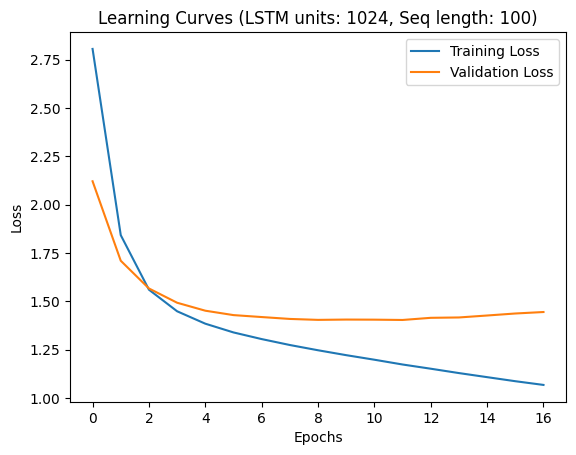

Epoch 1: Training Loss = 2.8061554431915283, Validation Loss = 2.1210806369781494
Epoch 2: Training Loss = 1.8421483039855957, Validation Loss = 1.7096600532531738
Epoch 3: Training Loss = 1.5598334074020386, Validation Loss = 1.566114068031311
Epoch 4: Training Loss = 1.4480112791061401, Validation Loss = 1.4922236204147339
Epoch 5: Training Loss = 1.3838027715682983, Validation Loss = 1.451017141342163
Epoch 6: Training Loss = 1.3385001420974731, Validation Loss = 1.4282093048095703
Epoch 7: Training Loss = 1.304097056388855, Validation Loss = 1.4181432723999023
Epoch 8: Training Loss = 1.2733871936798096, Validation Loss = 1.408379316329956
Epoch 9: Training Loss = 1.2462273836135864, Validation Loss = 1.4035232067108154
Epoch 10: Training Loss = 1.2208315134048462, Validation Loss = 1.4051212072372437
Epoch 11: Training Loss = 1.1972441673278809, Validation Loss = 1.404601812362671
Epoch 12: Training Loss = 1.1724932193756104, Validation Loss = 1.4030213356018066
Epoch 13: Training

In [14]:
lstm_units_list = [1024] #[512, 1024]
seq_length_list = [100]  #[50, 100]

for lstm_units in lstm_units_list:
    for seq_length in seq_length_list:
        print(f"\nTraining with {lstm_units} LSTM units and sequence length {seq_length}")
        history, lstm_model = train_and_evaluate_lstm(lstm_units, seq_length)
        print("lstm model", lstm_model)
        # Plot the learning curves
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'Learning Curves (LSTM units: {lstm_units}, Seq length: {seq_length})')
        plt.legend()
        plt.show()
        
        # Print the training and validation loss for each epoch
        for epoch in range(len(history.history['loss'])):
            print(f"Epoch {epoch + 1}: Training Loss = {history.history['loss'][epoch]}, Validation Loss = {history.history['val_loss'][epoch]}")
        
        # Generate and display text at 5 breakpoints
        breakpoints = [20]     #[5, 10, 15, 20]
        for epoch in breakpoints:
            print(f"\n--- Text generated after epoch {epoch} ---")
            start_string = 'JULIET'      #train_text[:50]  # Use the first 50 characters of the training text as the start string
            print(generate_text(lstm_model, lstm_units=lstm_units, start_string=start_string, num_generate=1000))